# Fraud Detection: Cross-Domain Generalization (Kaggle + PaySim)
Run each cell in order (Shift+Enter). Upload `fraud_data.csv` and `transactions_train.csv` when prompted.

In [6]:
from google.colab import files
uploaded = files.upload()


Saving fraud_data.csv to fraud_data.csv
Saving transactions_train.csv to transactions_train.csv


In [19]:
!pip install -q imbalanced-learn xgboost


In [7]:
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve, precision_recall_curve, average_precision_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

RANDOM_STATE = 42
FEATURE_COLS = ['amount_log', 'time_seconds', 'hour', 'day_of_week', 'is_weekend', 'is_night']


## Helper functions

In [8]:
def balanced_downsample(data, target_size, random_state=RANDOM_STATE):

    if len(data) <= target_size:
        return data

    fraud = data[data['label'] == 1]
    normal_candidates = data[data['label'] == 0]

    num_fraud = min(len(fraud), target_size // 2) if len(fraud) > 0 else 0
    num_fraud = max(num_fraud, 1) if len(fraud) > 0 else 0
    num_normal = max(target_size - num_fraud, 1) if len(normal_candidates) > 0 else 0

    fraud_sampled = fraud.sample(n=min(len(fraud), num_fraud), random_state=random_state) if num_fraud > 0 else fraud
    normal_sampled = normal_candidates.sample(n=min(len(normal_candidates), num_normal), random_state=random_state) if num_normal > 0 else normal_candidates

    return pd.concat([fraud_sampled, normal_sampled]).sample(frac=1, random_state=random_state)


In [9]:
def scale_df(df, scalers):

    X_scaled = np.zeros((len(df), len(FEATURE_COLS)))
    for source, scaler in scalers.items():
        mask = (df['source'] == source).values
        if mask.any():
            X_scaled[mask] = scaler.transform(df.loc[mask, FEATURE_COLS].values)
    return X_scaled


In [10]:
def train_and_evaluate(train_df, test_df, title, scalers, use_smote=True, algorithm='xgboost'):
    X_train_scaled = scale_df(train_df, scalers)
    y_train = train_df['label'].values
    X_test_scaled = scale_df(test_df, scalers)
    y_test = test_df['label'].values

    class_counts = Counter(y_train)
    X_train_resampled, y_train_resampled = X_train_scaled, y_train

    if use_smote and len(class_counts) == 2:
        min_count = min(class_counts.values())
        max_count = max(class_counts.values())

        if min_count < max_count:
            try:
                smote = SMOTE(sampling_strategy=1.0, random_state=RANDOM_STATE)
                X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
                under = RandomUnderSampler(sampling_strategy=1.0, random_state=RANDOM_STATE)
                X_train_resampled, y_train_resampled = under.fit_resample(X_train_resampled, y_train_resampled)
            except (ValueError, RuntimeError) as e:
                print(f"[warning] resampling failed for '{title}', falling back to unresampled data: {e}")
                X_train_resampled, y_train_resampled = X_train_scaled, y_train

    pos, neg = (y_train_resampled == 1).sum(), (y_train_resampled == 0).sum()
    if algorithm =='xgboost':
        model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
                          colsample_bytree=0.8, scale_pos_weight=neg/max(pos,1),
                          random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss')

    elif algorithm == 'logistic_regression':
          model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)

    else:
        raise ValueError(f"Unknown algorithm: {algorithm}")

    model.fit(X_train_resampled, y_train_resampled)

    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        'title': title,'algorithm':algorithm, 'roc_auc': roc_auc_score(y_test, y_prob),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'cm': confusion_matrix(y_test, y_pred)
    }
    metrics['fpr'], metrics['tpr'], _ = roc_curve(y_test, y_prob)
    metrics['prec_curve'], metrics['rec_curve'], _ = precision_recall_curve(y_test, y_prob)

    return metrics, model


## Load data and engineer features

In [11]:
kaggle = pd.read_csv('fraud_data.csv')
paysim = pd.read_csv('transactions_train.csv')

kaggle['TransactionDate'] = pd.to_datetime(kaggle['trans_date_trans_time'], errors='coerce')
kaggle = kaggle.dropna(subset=['TransactionDate'])
kaggle['time_seconds'] = (kaggle['TransactionDate'] - kaggle['TransactionDate'].min()).dt.total_seconds()
kaggle['hour'] = kaggle['TransactionDate'].dt.hour
kaggle['day_of_week'] = kaggle['TransactionDate'].dt.dayofweek
kaggle['is_weekend'] = (kaggle['day_of_week'] >= 5).astype(int)
kaggle['is_night'] = ((kaggle['hour'] >= 22) | (kaggle['hour'] <= 6)).astype(int)
kaggle['amount'] = pd.to_numeric(kaggle['amt'], errors='coerce')
kaggle['amount_log'] = np.log1p(kaggle['amount'])
kaggle['label'] = pd.to_numeric(kaggle['is_fraud'], errors='coerce').fillna(0).astype(int)
kaggle['source'] = 'kaggle'
k_data = kaggle[FEATURE_COLS + ['label', 'source']].dropna()

paysim['time_seconds'] = paysim['step'].astype(float) * 3600
paysim['hour'] = (paysim['step'] % 24).astype(int)
paysim['day_of_week'] = ((paysim['step'] // 24) % 7).astype(int)
paysim['is_weekend'] = (paysim['day_of_week'] >= 5).astype(int)
paysim['is_night'] = ((paysim['hour'] >= 22) | (paysim['hour'] <= 6)).astype(int)
paysim['amount_log'] = np.log1p(paysim['amount'].astype(float))
paysim['label'] = paysim['isFraud'].astype(int)
paysim['source'] = 'paysim'
p_data = paysim[FEATURE_COLS + ['label', 'source']].dropna()


## Balance dataset sizes, split, and fit per-domain scalers

In [12]:
min_size = min(len(k_data), len(p_data))
target_size = int(min_size * 1.2)
k_data = balanced_downsample(k_data, target_size)
p_data = balanced_downsample(p_data, target_size)

k_train, k_test = train_test_split(k_data, test_size=0.2, stratify=k_data['label'], random_state=RANDOM_STATE)
p_train, p_test = train_test_split(p_data, test_size=0.2, stratify=p_data['label'], random_state=RANDOM_STATE)

scalers = {
    'kaggle': StandardScaler().fit(k_train[FEATURE_COLS].values),
    'paysim': StandardScaler().fit(p_train[FEATURE_COLS].values),
}


## Run the 4 cross-domain experiments

In [13]:
results = []
models = {}

experiment_configs = [
    (k_train,p_test, 'Exp 1 : Train kaggle, test paysim'),
    (p_train,k_test, 'Exp 2 : Train paysim, test kaggle'),
    (pd.concat([k_train, p_train]), k_test, 'Exp 3 : Train fused, test kaggle'),
    (pd.concat([k_train,p_train]), p_test, 'Exp 4 : Train fused, test paysim')
]
ALGORITHMS =['xgboost','logistic_regression']
for train_df, test_df, title in experiment_configs:
    for algo in ALGORITHMS :
        metrics, model = train_and_evaluate(train_df, test_df, title, scalers, algorithm=algo)
        results.append(metrics)
        models[f"{title}_{algo}"] = model

joblib.dump(models['Exp 3 : Train fused, test kaggle_xgboost'], 'model_fused_test_kaggle.pkl')
joblib.dump(scalers, 'domain_scalers.pkl')

['domain_scalers.pkl']

## Plots

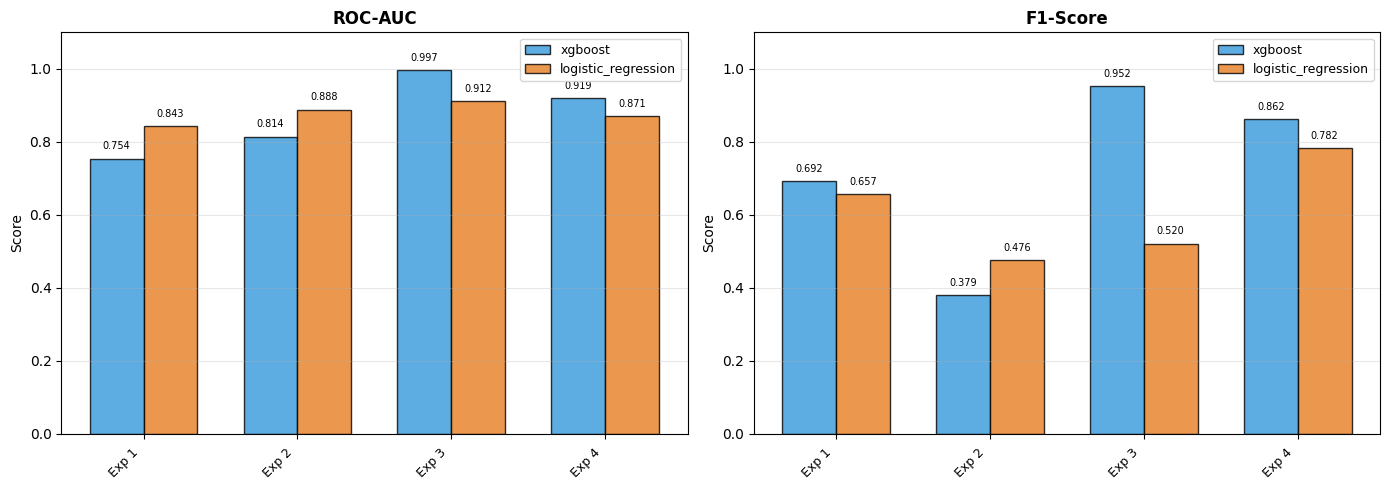

In [14]:
exp_titles = [c[2] for c in experiment_configs]
algo_colors = {'xgboost': '#3498db', 'logistic_regression': '#e67e22'}

def get_result(title, algo):
    return next(r for r in results if r['title'] == title and r['algorithm'] == algo)

x = np.arange(len(exp_titles))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ['roc_auc', 'f1'], ['ROC-AUC', 'F1-Score']):
    for i, algo in enumerate(ALGORITHMS):
        vals = [get_result(t, algo)[metric] for t in exp_titles]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=algo, color=algo_colors[algo], alpha=0.8, edgecolor='black')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([t.split(':')[0] for t in exp_titles], rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc_f1_comparison.png', dpi=150)
plt.show()


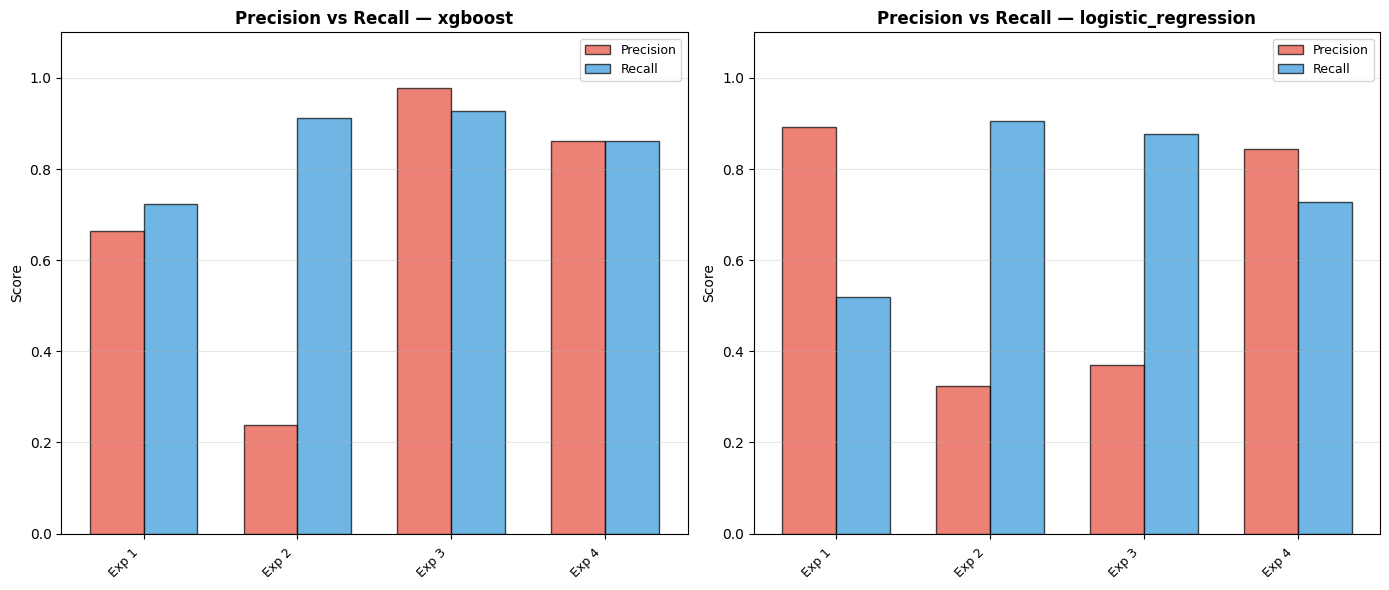

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, algo in zip(axes, ALGORITHMS):
    prec = [get_result(t, algo)['precision'] for t in exp_titles]
    rec = [get_result(t, algo)['recall'] for t in exp_titles]
    ax.bar(x - width/2, prec, width, label='Precision', color='#e74c3c', alpha=0.7, edgecolor='black')
    ax.bar(x + width/2, rec, width, label='Recall', color='#3498db', alpha=0.7, edgecolor='black')
    ax.set_title(f'Precision vs Recall — {algo}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([t.split(':')[0] for t in exp_titles], rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_comparison.png', dpi=150)
plt.show()


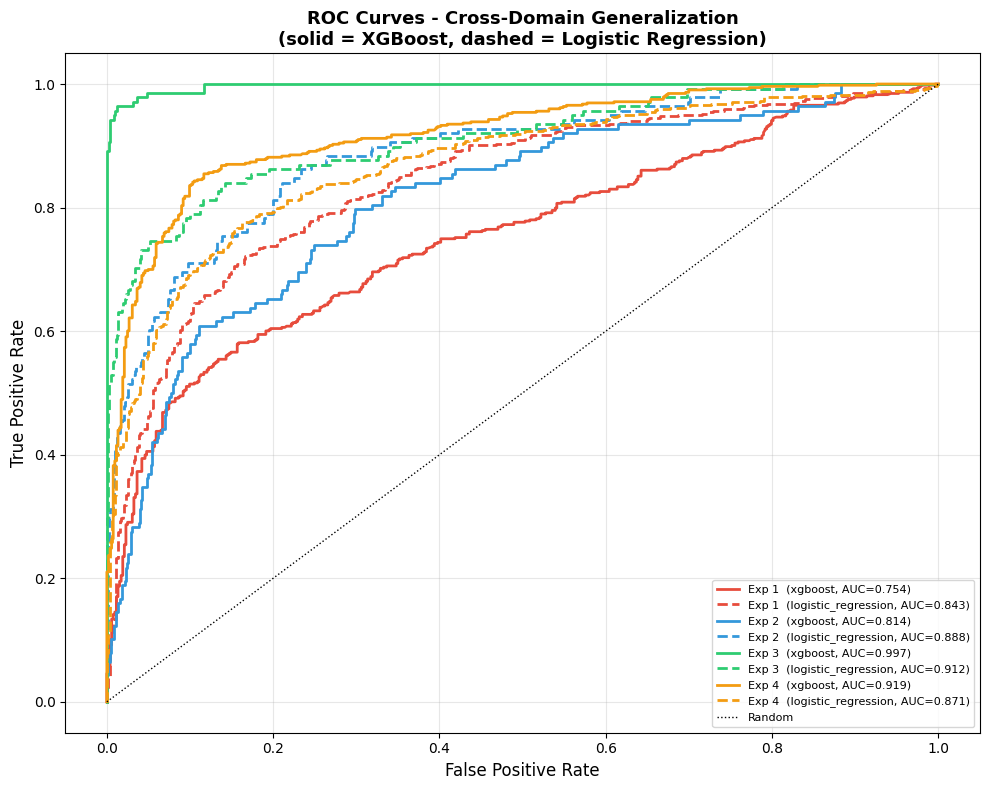

In [16]:
exp_colors = {t: c for t, c in zip(exp_titles, ['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])}
algo_linestyle = {'xgboost': '-', 'logistic_regression': '--'}

plt.figure(figsize=(10, 8))
for r in results:
    plt.plot(r['fpr'], r['tpr'], algo_linestyle[r['algorithm']], color=exp_colors[r['title']],
              linewidth=2, label=f"{r['title'].split(':')[0]} ({r['algorithm']}, AUC={r['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Cross-Domain Generalization\n(solid = XGBoost, dashed = Logistic Regression)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()


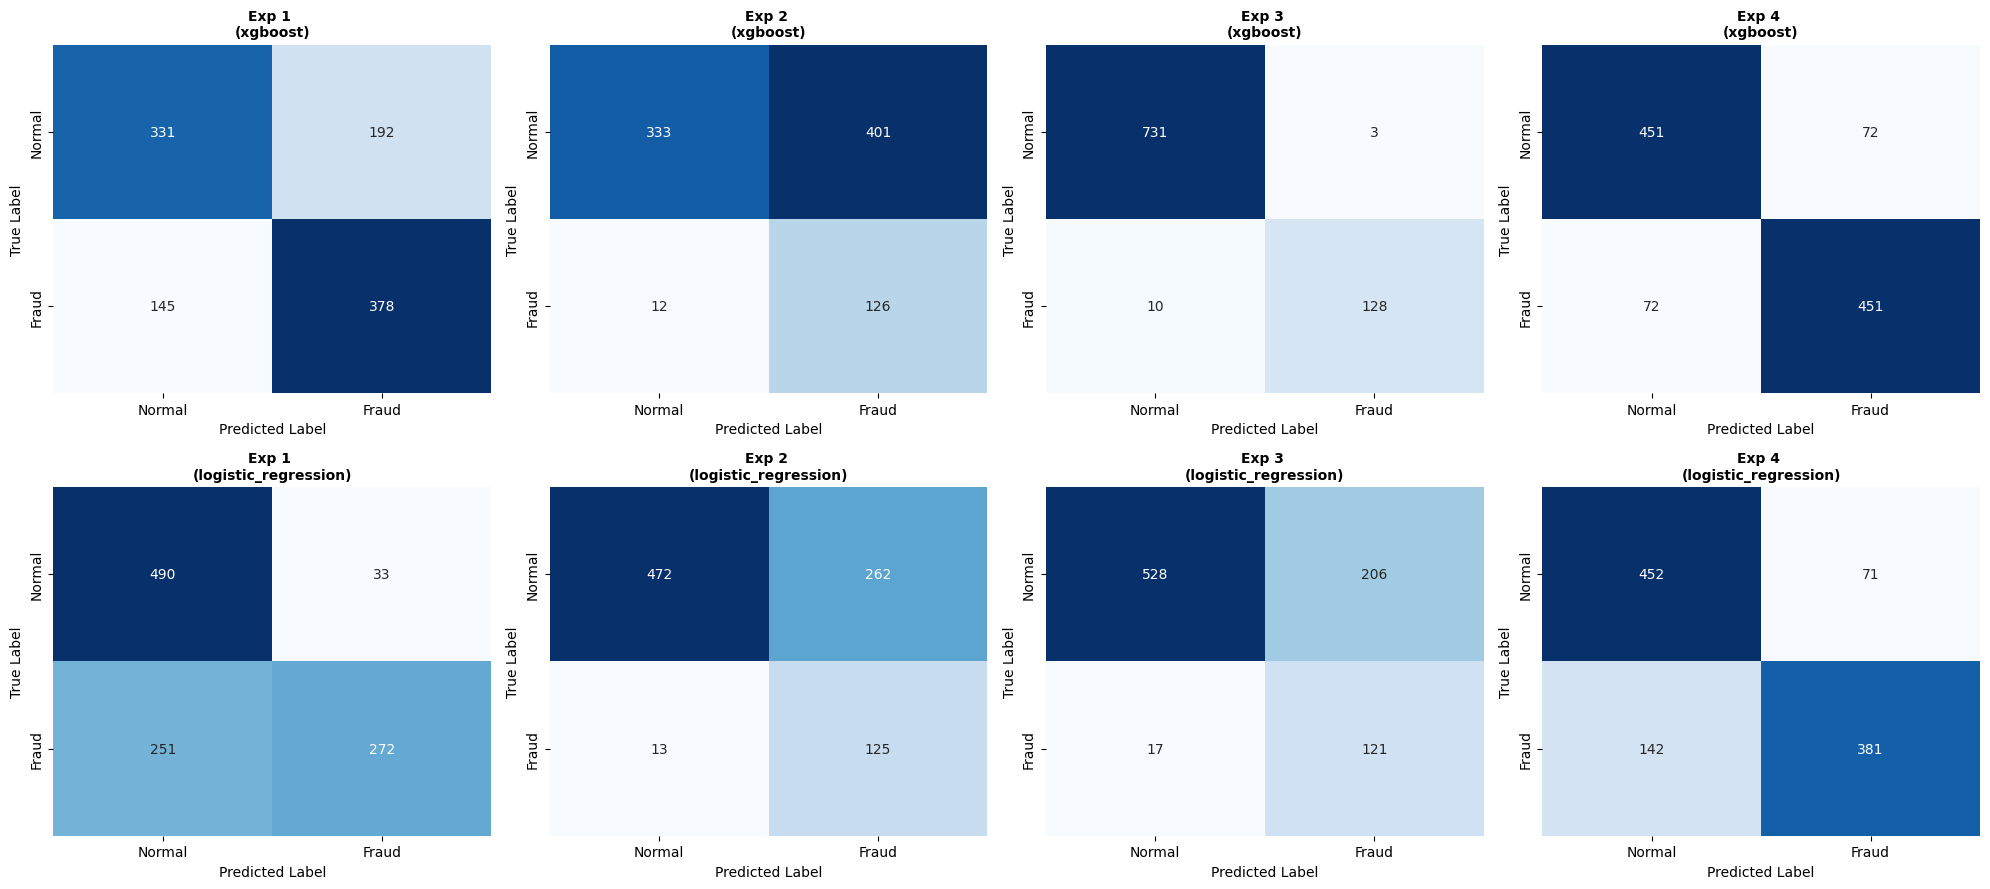

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for row, algo in enumerate(ALGORITHMS):
    for col, t in enumerate(exp_titles):
        r = get_result(t, algo)
        ax = axes[row, col]
        sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
        ax.set_title(f"{t.split(':')[0]}\n({algo})", fontsize=10, fontweight='bold')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()


## Summary table

In [18]:
summary_df = pd.DataFrame({
    ' Experiment ': [r['title'] for r in results],
    ' Algorithm ': [r['algorithm'] for r in results],
    ' ROC-AUC ': [f"{r['roc_auc']:.4f}" for r in results],
    ' F1 ': [f"{r['f1']:.4f}" for r in results],
    ' Precision ': [f"{r['precision']:.4f}" for r in results],
    ' Recall ': [f"{r['recall']:.4f}" for r in results]
})

print(summary_df.to_string(index=False))
summary_df.to_csv('results_summary.csv', index=False)

                      Experiment           Algorithm  ROC-AUC     F1  Precision  Recall 
Exp 1 : Train kaggle, test paysim             xgboost   0.7540 0.6917     0.6632  0.7228
Exp 1 : Train kaggle, test paysim logistic_regression   0.8429 0.6570     0.8918  0.5201
Exp 2 : Train paysim, test kaggle             xgboost   0.8141 0.3789     0.2391  0.9130
Exp 2 : Train paysim, test kaggle logistic_regression   0.8877 0.4762     0.3230  0.9058
 Exp 3 : Train fused, test kaggle             xgboost   0.9971 0.9517     0.9771  0.9275
 Exp 3 : Train fused, test kaggle logistic_regression   0.9117 0.5204     0.3700  0.8768
 Exp 4 : Train fused, test paysim             xgboost   0.9191 0.8623     0.8623  0.8623
 Exp 4 : Train fused, test paysim logistic_regression   0.8707 0.7815     0.8429  0.7285
